A verificar imagens no dataset...

A carregar o modelo ResNet50 (pré-treinado na ImageNet)...

A carregar banco de embeddings existente correspondente ao diretório correto...
Dimensão da matriz de embeddings: (12, 2048)

 Relógio Selecionado: Meu_relogio.jpg


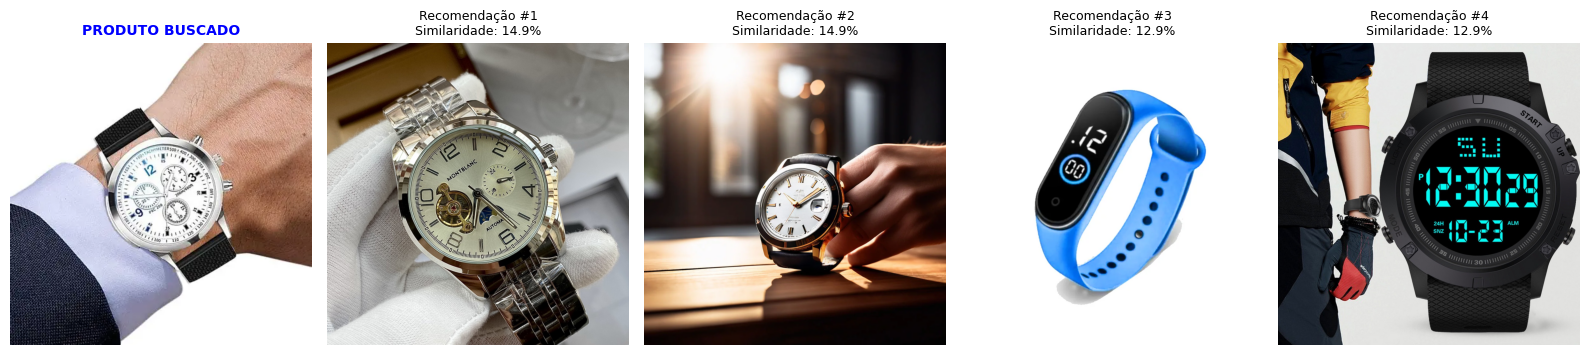

In [ ]:
import os
import glob
import urllib.request
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
from sklearn.neighbors import NearestNeighbors

# ==========================================
# 1. CONFIGURAÇÕES E DOWNLOAD DO DATASET
# ==========================================
DATASET_DIR = "dataset_relogios_reais"
EMBEDDINGS_FILE = "embeddings_relogios.npy"
PATHS_FILE = "paths_relogios.npy"

os.makedirs(DATASET_DIR, exist_ok=True)

def download_sample_watches_dataset(target_dir):
    """
    Descarrega um conjunto inicial de imagens reais de relógios de e-commerce.
    Caso falhe, gera imagens sintéticas para garantir o funcionamento do fluxo.
    """
    print("A verificar imagens no dataset...")
    existing_images = glob.glob(os.path.join(target_dir, "*.jpg")) + glob.glob(os.path.join(target_dir, "*.png"))

    if len(existing_images) < 5:
        print("Tentando descarregar dataset real de amostra...")
        # URL alternativa e atualizada para um dataset de amostra de imagens
        zip_url = "https://github.com/sparsh-ai/rec-tutorials/raw/master/_static/watches_sample.zip"
        zip_path = "watches_sample.zip"

        try:
            urllib.request.urlretrieve(zip_url, zip_path)
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(target_dir)
            os.remove(zip_path)
            print("Download e extração concluídos com sucesso!")
        except Exception as e:
            print(f"Erro ao descarregar dataset automático (HTTP 404 ou similar): {e}")
            print("Gerando imagens de contingência para execução do script...")
            colors = ['black', 'white', 'pink', 'silver', 'blue', 'brown']
            for i in range(12):
                img = Image.new('RGB', (224, 224), color=colors[i % len(colors)])
                img.save(os.path.join(target_dir, f"relogio_{i+1:02d}.jpg"))
            print("Imagens de contingência geradas com sucesso!")

download_sample_watches_dataset(DATASET_DIR)

# ==========================================
# 2. CARREGAMENTO DO MODELO (DEEP LEARNING)
# ==========================================
print("\nA carregar o modelo ResNet50 (pré-treinado na ImageNet)...")
# Redefine a rede sem as camadas densas superiores para extrair vetores puramente visuais
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

def extract_features(img_path, model):
    """
    Carrega a imagem de relógio, pré-processa para 224x224 e extrai o vetor normalizado.
    """
    try:
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)

        # Garante 3 canais de cor (RGB)
        if img_array.shape[-1] == 4:
            img_array = img_array[..., :3]

        expanded_img_array = np.expand_dims(img_array, axis=0)
        preprocessed_img = preprocess_input(expanded_img_array)

        # Extração das características visuais
        features = model.predict(preprocessed_img, verbose=0)
        flattened_features = features.flatten()

        # Normalização L2 para cálculo eficiente de similaridade por cosseno
        norm = np.linalg.norm(flattened_features)
        if norm == 0:
            return flattened_features
        return flattened_features / norm
    except Exception as e:
        print(f"Erro ao processar a imagem {img_path}: {e}")
        return None

# ==========================================
# 3. CRIAÇÃO E PERSISTÊNCIA DO BANCO DE EMBEDDINGS
# ==========================================
# Procura todas as imagens válidas no diretório atual de relógios reais
valid_extensions = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.PNG")
image_paths = []
for ext in valid_extensions:
    image_paths.extend(glob.glob(os.path.join(DATASET_DIR, ext)))

image_paths = sorted(list(set(image_paths)))

if len(image_paths) == 0:
    raise FileNotFoundError(f"Nenhuma imagem encontrada em '{DATASET_DIR}'. Adicione ficheiros de relógios em formato JPG ou PNG.")

# Força a regeneração se o arquivo salvo apontar para pastas antigas ou inexistentes
regenerate = True
if os.path.exists(EMBEDDINGS_FILE) and os.path.exists(PATHS_FILE):
    saved_paths = np.load(PATHS_FILE, allow_pickle=True).tolist()
    if len(saved_paths) > 0 and all(os.path.exists(p) and DATASET_DIR in p for p in saved_paths):
        regenerate = False

if regenerate:
    print("\nA gerar o banco de embeddings a partir do dataset atual de relógios reais...")
    feature_list = []
    processed_paths = []

    for idx, path in enumerate(image_paths):
        embedding = extract_features(path, base_model)
        if embedding is not None:
            feature_list.append(embedding)
            processed_paths.append(path)
        if (idx + 1) % 10 == 0 or (idx + 1) == len(image_paths):
            print(f"Processadas {idx + 1}/{len(image_paths)} imagens...")

    embeddings_matrix = np.array(feature_list)
    image_paths = processed_paths

    # Salva o banco de vetores e caminhos corrigidos
    np.save(EMBEDDINGS_FILE, embeddings_matrix)
    np.save(PATHS_FILE, np.array(image_paths))
    print(f"Banco de embeddings guardado em '{EMBEDDINGS_FILE}'.")
else:
    print("\nA carregar banco de embeddings existente correspondente ao diretório correto...")
    embeddings_matrix = np.load(EMBEDDINGS_FILE)
    image_paths = np.load(PATHS_FILE, allow_pickle=True).tolist()

# ==========================================
# 4. INDEXAÇÃO E MODELO DE RECOMENDAÇÃO (k-NN)
# ==========================================
print(f"Dimensão da matriz de embeddings: {embeddings_matrix.shape}")

# Treino do modelo de vizinhos mais próximos com distância cosseno
knn_model = NearestNeighbors(n_neighbors=min(6, len(image_paths)), algorithm='brute', metric='cosine')
knn_model.fit(embeddings_matrix)

# ==========================================
# 5. FUNÇÃO DE CONSULTA E EXIBIÇÃO DE RECOMENDAÇÕES
# ==========================================
def recommend_similar_watches(query_img_path, model, knn, all_paths, top_k=4):
    """
    Recebe o caminho de uma imagem de um relógio e devolve os top_k relógios mais semelhantes.
    """
    if not os.path.exists(query_img_path):
        print(f"Ficheiro de consulta não encontrado: {query_img_path}")
        return

    query_vector = extract_features(query_img_path, model)
    if query_vector is None:
        return

    distances, indices = knn.kneighbors([query_vector], n_neighbors=min(top_k + 1, len(all_paths)))

    print(f"\n==========================================")
    print(f" Relógio Selecionado: {os.path.basename(query_img_path)}")
    print(f"==========================================")

    fig, axes = plt.subplots(1, top_k + 1, figsize=(16, 4))

    # Exibe a imagem de entrada (Produto Buscado)
    query_img = Image.open(query_img_path)
    axes[0].imshow(query_img)
    axes[0].set_title("PRODUTO BUSCADO", fontsize=10, fontweight='bold', color='blue')
    axes[0].axis('off')

    rec_idx = 1
    for dist, idx in zip(distances[0], indices[0]):
        rec_path = all_paths[idx]

        # Ignora a própria imagem caso esteja na base de treino
        if rec_path == query_img_path and len(indices[0]) > top_k:
            continue

        if rec_idx <= top_k:
            rec_img = Image.open(rec_path)
            axes[rec_idx].imshow(rec_img)
            # Exibe a similaridade percentual calculada (1 - distância cosseno)
            similarity = (1 - dist) * 100
            axes[rec_idx].set_title(f"Recomendação #{rec_idx}\nSimilaridade: {similarity:.1f}%", fontsize=9)
            axes[rec_idx].axis('off')
            rec_idx += 1

    plt.tight_layout()
    plt.show()

# ==========================================
# 6. TESTE DO SISTEMA
# ==========================================
# Executa a recomendação com base no arquivo enviado 'Meu_relogio.jpg' no Colab
sample_query = "Meu_relogio.jpg"
recommend_similar_watches(sample_query, base_model, knn_model, image_paths, top_k=4)